In [559]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score,f1_score,confusion_matrix,recall_score
from sklearn.model_selection import train_test_split


In [560]:
df=pd.read_csv('telecom_churn.csv')

In [561]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [562]:
df.count()

customer_id             243553
telecom_partner         243553
gender                  243553
age                     243553
state                   243553
city                    243553
pincode                 243553
date_of_registration    243553
num_dependents          243553
estimated_salary        243553
calls_made              243553
sms_sent                243553
data_used               243553
churn                   243553
dtype: int64

In [563]:
df.isnull().sum()

customer_id             0
telecom_partner         0
gender                  0
age                     0
state                   0
city                    0
pincode                 0
date_of_registration    0
num_dependents          0
estimated_salary        0
calls_made              0
sms_sent                0
data_used               0
churn                   0
dtype: int64

churn
0    194726
1     48827
Name: count, dtype: int64


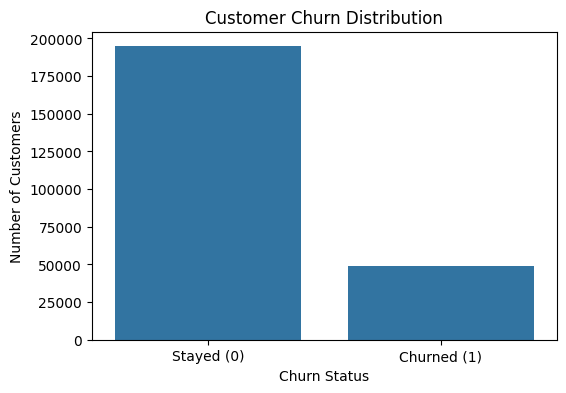

In [564]:


import seaborn as sns

# Load dataset
df1 = pd.read_csv("telecom_churn.csv")
# Count churn values
print(df['churn'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df1)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn Status')
plt.ylabel('Number of Customers')

plt.xticks([0,1], ['Stayed (0)', 'Churned (1)'])

plt.show()

In [565]:
df.head()

,customer_id,telecom_partner,gender,age,state,city,pincode,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn
0,1,Reliance Jio,F,25,Karnataka,Kolkata,755597,2020-01-01,4,124962,44,45,-361,0
1,2,Reliance Jio,F,55,Mizoram,Mumbai,125926,2020-01-01,2,130556,62,39,5973,0
2,3,Vodafone,F,57,Arunachal Pradesh,Delhi,423976,2020-01-01,0,148828,49,24,193,1
3,4,BSNL,M,46,Tamil Nadu,Kolkata,522841,2020-01-01,1,38722,80,25,9377,1
4,5,BSNL,F,26,Tripura,Delhi,740247,2020-01-01,2,55098,78,15,1393,0


In [566]:
df.drop('customer_id',axis=1,inplace=True)

In [567]:
df.drop(['state','pincode',],axis=1,inplace=True)

In [568]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 243553 entries, 0 to 243552
Data columns (total 11 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   telecom_partner       243553 non-null  str  
 1   gender                243553 non-null  str  
 2   age                   243553 non-null  int64
 3   city                  243553 non-null  str  
 4   date_of_registration  243553 non-null  str  
 5   num_dependents        243553 non-null  int64
 6   estimated_salary      243553 non-null  int64
 7   calls_made            243553 non-null  int64
 8   sms_sent              243553 non-null  int64
 9   data_used             243553 non-null  int64
 10  churn                 243553 non-null  int64
dtypes: int64(7), str(4)
memory usage: 20.4 MB


In [569]:
df['telecom_partner'].unique().tolist()

['Reliance Jio', 'Vodafone', 'BSNL', 'Airtel']

telecom_partner
Reliance Jio    61123
Airtel          60905
Vodafone        60802
BSNL            60723
Name: count, dtype: int64


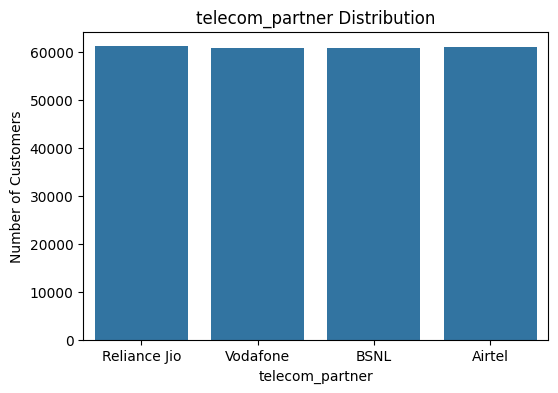

In [570]:


import seaborn as sns

# Load dataset
df2 = pd.read_csv("telecom_churn.csv")
# Count churn values
print(df['telecom_partner'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='telecom_partner', data=df2)

plt.title('telecom_partner Distribution')
plt.xlabel('telecom_partner')
plt.ylabel('Number of Customers')


plt.show()

In [571]:
import pandas as pd

# One-Hot Encoding for company column
df = pd.get_dummies(df, columns=['telecom_partner'])

# View result
print(df.head())

  gender  age     city date_of_registration  num_dependents  estimated_salary  \
0      F   25  Kolkata           2020-01-01               4            124962   
1      F   55   Mumbai           2020-01-01               2            130556   
2      F   57    Delhi           2020-01-01               0            148828   
3      M   46  Kolkata           2020-01-01               1             38722   
4      F   26    Delhi           2020-01-01               2             55098   

   calls_made  sms_sent  data_used  churn  telecom_partner_Airtel  \
0          44        45       -361      0                   False   
1          62        39       5973      0                   False   
2          49        24        193      1                   False   
3          80        25       9377      1                   False   
4          78        15       1393      0                   False   

   telecom_partner_BSNL  telecom_partner_Reliance Jio  \
0                 False                  

city
Chennai      40749
Hyderabad    40698
Kolkata      40661
Bangalore    40603
Delhi        40456
Mumbai       40386
Name: count, dtype: int64


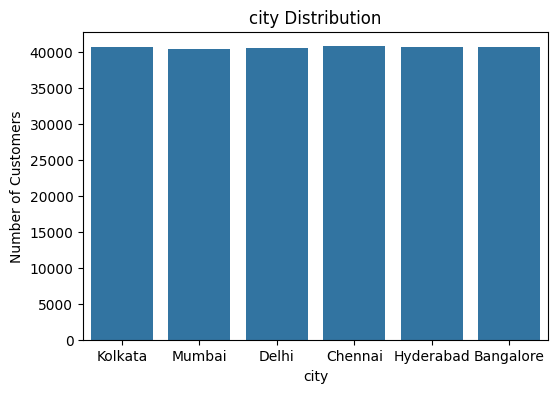

In [572]:


import seaborn as sns

# Load dataset
df3 = pd.read_csv("telecom_churn.csv")
# Count churn values
print(df['city'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='city', data=df3)

plt.title('city Distribution')
plt.xlabel('city')
plt.ylabel('Number of Customers')


plt.show()

In [573]:
import pandas as pd

# One-Hot Encoding for company column
df = pd.get_dummies(df, columns=['city'], drop_first=True)

# View result
print(df.head())

  gender  age date_of_registration  num_dependents  estimated_salary  \
0      F   25           2020-01-01               4            124962   
1      F   55           2020-01-01               2            130556   
2      F   57           2020-01-01               0            148828   
3      M   46           2020-01-01               1             38722   
4      F   26           2020-01-01               2             55098   

   calls_made  sms_sent  data_used  churn  telecom_partner_Airtel  \
0          44        45       -361      0                   False   
1          62        39       5973      0                   False   
2          49        24        193      1                   False   
3          80        25       9377      1                   False   
4          78        15       1393      0                   False   

   telecom_partner_BSNL  telecom_partner_Reliance Jio  \
0                 False                          True   
1                 False               

In [574]:
df

,gender,age,date_of_registration,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai
0,F,25,2020-01-01,4,124962,44,45,-361,0,False,False,True,False,False,False,False,True,False
1,F,55,2020-01-01,2,130556,62,39,5973,0,False,False,True,False,False,False,False,False,True
2,F,57,2020-01-01,0,148828,49,24,193,1,False,False,False,True,False,True,False,False,False
3,M,46,2020-01-01,1,38722,80,25,9377,1,False,True,False,False,False,False,False,True,False
4,F,26,2020-01-01,2,55098,78,15,1393,0,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243548,F,28,2023-05-03,3,130580,28,9,4102,0,True,False,False,False,False,False,False,True,False
243549,F,52,2023-05-03,0,82393,80,45,7521,0,False,False,True,False,False,False,False,True,False
243550,M,59,2023-05-03,4,51298,26,4,6547,0,False,False,True,False,False,False,False,True,False
243551,M,49,2023-05-03,2,83981,80,15,1125,0,False,True,False,False,False,False,False,True,False


num_dependents
0    48927
1    48701
3    48694
4    48626
2    48605
Name: count, dtype: int64


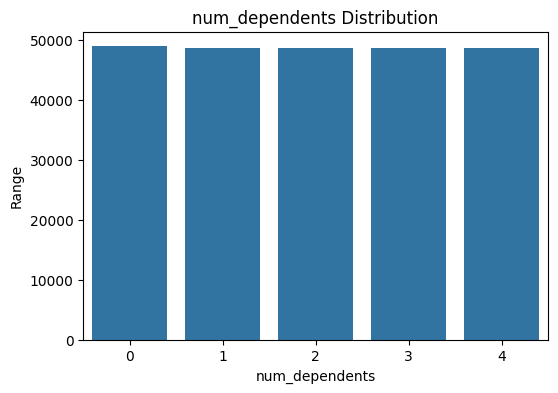

In [575]:


import seaborn as sns

# Load dataset
df4 = pd.read_csv("telecom_churn.csv")
# Count churn values
print(df['num_dependents'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='num_dependents', data=df4)

plt.title('num_dependents Distribution')
plt.xlabel('num_dependents')
plt.ylabel('Range')


plt.show()

gender
M    145977
F     97576
Name: count, dtype: int64


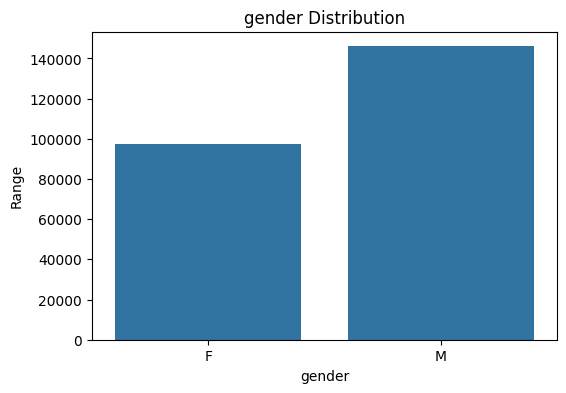

In [576]:


import seaborn as sns

# Load dataset
df5 = pd.read_csv("telecom_churn.csv")
# Count churn values
print(df['gender'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df5)

plt.title('gender Distribution')
plt.xlabel('gender')
plt.ylabel('Range')


plt.show()

In [577]:
df['date_of_registration'] = pd.to_datetime(df['date_of_registration'])
df['tenure_days'] = (pd.to_datetime('today') - df['date_of_registration']).dt.days
df = df.drop('date_of_registration', axis=1)

In [578]:
df['gender'] = df['gender'].map({'M': 1, 'F': 0})

In [579]:
df

,gender,age,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai,tenure_days
0,0,25,4,124962,44,45,-361,0,False,False,True,False,False,False,False,True,False,2350
1,0,55,2,130556,62,39,5973,0,False,False,True,False,False,False,False,False,True,2350
2,0,57,0,148828,49,24,193,1,False,False,False,True,False,True,False,False,False,2350
3,1,46,1,38722,80,25,9377,1,False,True,False,False,False,False,False,True,False,2350
4,0,26,2,55098,78,15,1393,0,False,True,False,False,False,True,False,False,False,2350
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
243548,0,28,3,130580,28,9,4102,0,True,False,False,False,False,False,False,True,False,1132
243549,0,52,0,82393,80,45,7521,0,False,False,True,False,False,False,False,True,False,1132
243550,1,59,4,51298,26,4,6547,0,False,False,True,False,False,False,False,True,False,1132
243551,1,49,2,83981,80,15,1125,0,False,True,False,False,False,False,False,True,False,1132


age
60    4424
51    4423
48    4414
62    4402
38    4392
37    4391
63    4378
66    4349
50    4341
42    4337
61    4331
44    4329
29    4329
65    4327
55    4325
71    4317
24    4316
19    4314
67    4313
53    4312
68    4301
23    4299
73    4297
72    4294
70    4290
20    4287
49    4283
69    4278
22    4271
33    4265
47    4264
28    4264
59    4262
21    4259
56    4257
39    4256
30    4254
54    4254
46    4248
40    4248
27    4229
64    4228
32    4228
36    4218
34    4212
31    4211
35    4199
57    4190
43    4187
74    4179
58    4154
41    4153
25    4152
52    4141
45    4138
18    4128
26    4111
Name: count, dtype: int64


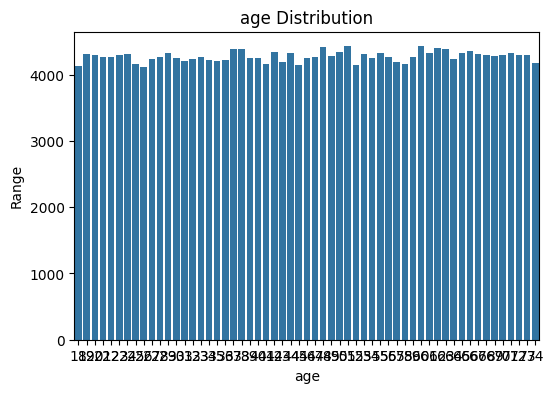

In [580]:


import seaborn as sns

# Load dataset
df4 = pd.read_csv("telecom_churn.csv")
# Count churn values
print(df['age'].value_counts())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='age', data=df4)

plt.title('age Distribution')
plt.xlabel('age')
plt.ylabel('Range')


plt.show()

In [581]:
from imblearn.over_sampling import SMOTE

X = df.drop('churn', axis=1)
y = df['churn']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

churn
0    194726
1    194726
Name: count, dtype: int64


In [582]:
df.head()



,gender,age,num_dependents,estimated_salary,calls_made,sms_sent,data_used,churn,telecom_partner_Airtel,telecom_partner_BSNL,telecom_partner_Reliance Jio,telecom_partner_Vodafone,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai,tenure_days
0,0,25,4,124962,44,45,-361,0,False,False,True,False,False,False,False,True,False,2350
1,0,55,2,130556,62,39,5973,0,False,False,True,False,False,False,False,False,True,2350
2,0,57,0,148828,49,24,193,1,False,False,False,True,False,True,False,False,False,2350
3,1,46,1,38722,80,25,9377,1,False,True,False,False,False,False,False,True,False,2350
4,0,26,2,55098,78,15,1393,0,False,True,False,False,False,True,False,False,False,2350


In [583]:
import category_encoders as ce

encoder = ce.BinaryEncoder(cols=['city_Chennai','city_Delhi','city_Hyderabad','city_Kolkata','city_Mumbai','telecom_partner_BSNL','telecom_partner_Reliance Jio','telecom_partner_Vodafone','telecom_partner_Airtel','gender'])

df = encoder.fit_transform(df)

In [584]:
X_train1, X_test1, y_train1, y_test1= train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [585]:
X_train2, X_test2, y_train2, y_test2= train_test_split(X_resampled,y_resampled,test_size=0.2,random_state=42)

In [586]:
df.columns.value_counts().sum()

np.int64(28)

In [587]:
df.corr()['churn']

gender_0                         -0.005089
gender_1                          0.005089
age                               0.000839
num_dependents                   -0.002543
estimated_salary                 -0.003332
calls_made                        0.001692
sms_sent                         -0.003072
data_used                         0.000732
churn                             1.000000
telecom_partner_Airtel_0          0.004592
telecom_partner_Airtel_1         -0.004592
telecom_partner_BSNL_0           -0.002693
telecom_partner_BSNL_1            0.002693
telecom_partner_Reliance Jio_0    0.000469
telecom_partner_Reliance Jio_1   -0.000469
telecom_partner_Vodafone_0       -0.001433
telecom_partner_Vodafone_1        0.001433
city_Chennai_0                   -0.003277
city_Chennai_1                    0.003277
city_Delhi_0                     -0.003321
city_Delhi_1                      0.003321
city_Hyderabad_0                  0.004122
city_Hyderabad_1                 -0.004122
city_Kolkat

In [588]:
print(y_train1.value_counts())
print(y_test1.value_counts())

churn
1    155918
0    155643
Name: count, dtype: int64
churn
0    39083
1    38808
Name: count, dtype: int64


In [589]:
dtc=DecisionTreeClassifier(max_depth=None,min_samples_split=2,random_state=42,class_weight='balanced')


In [590]:
dtc.fit(X_train1,y_train1)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [591]:
print(y_train1.value_counts())
print(y_test1.value_counts())

print(y_train1.value_counts(normalize=True) * 100)

churn
1    155918
0    155643
Name: count, dtype: int64
churn
0    39083
1    38808
Name: count, dtype: int64
churn
1    50.044133
0    49.955867
Name: proportion, dtype: float64


In [592]:
y_pred1=dtc.predict(X_test1)

In [593]:
print(np.unique(y_pred1, return_counts=True))

(array([0, 1]), array([37958, 39933]))


In [594]:
confusion_matrix(y_test1,y_pred1)

array([[28791, 10292],
       [ 9167, 29641]])

In [595]:
accuracy_score(y_test1,y_pred1)

0.7501765287388786

In [596]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=100,class_weight='balanced')


In [597]:
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train2)

# Transform test data
X_test_scaled = scaler.transform(X_test2)

In [598]:
lr.fit(X_train_scaled,y_train2)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [599]:
y_pred2=lr.predict(X_test_scaled)

In [600]:
accuracy_score(y_test2,y_pred2)

0.8076671245715166

In [601]:
confusion_matrix(y_test2,y_pred2)

array([[34408,  4675],
       [10306, 28502]])

In [602]:
from sklearn.metrics import classification_report

print(classification_report(y_test2, y_pred2))

              precision    recall  f1-score   support

           0       0.77      0.88      0.82     39083
           1       0.86      0.73      0.79     38808

    accuracy                           0.81     77891
   macro avg       0.81      0.81      0.81     77891
weighted avg       0.81      0.81      0.81     77891



In [603]:
recall_score(y_test2,y_pred2)

0.734436198721913

In [604]:
f1_score(y_test2,y_pred2)

0.791887198721956

In [605]:
print(y_train2.value_counts())
print(y_test2.value_counts())

print(y_train2.value_counts(normalize=True) * 100)

churn
1    155918
0    155643
Name: count, dtype: int64
churn
0    39083
1    38808
Name: count, dtype: int64
churn
1    50.044133
0    49.955867
Name: proportion, dtype: float64
